In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
raw_data_dir = Path("../data/raw_data")

ml_dir = raw_data_dir / "ml-1m"
ml_fname = "movielens_ratings_with_info.csv"

ml_df = pd.read_csv(ml_dir / ml_fname)

In [3]:
ml_df.head(5)

,user_id,item_id,rating,timestamp,title,genres,gender,age,occupation,zipcode
0,1,1193,5,2000-12-31 22:12:40,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,2000-12-31 22:35:09,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,2000-12-31 22:32:48,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,2000-12-31 22:04:35,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,2001-01-06 23:38:11,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067


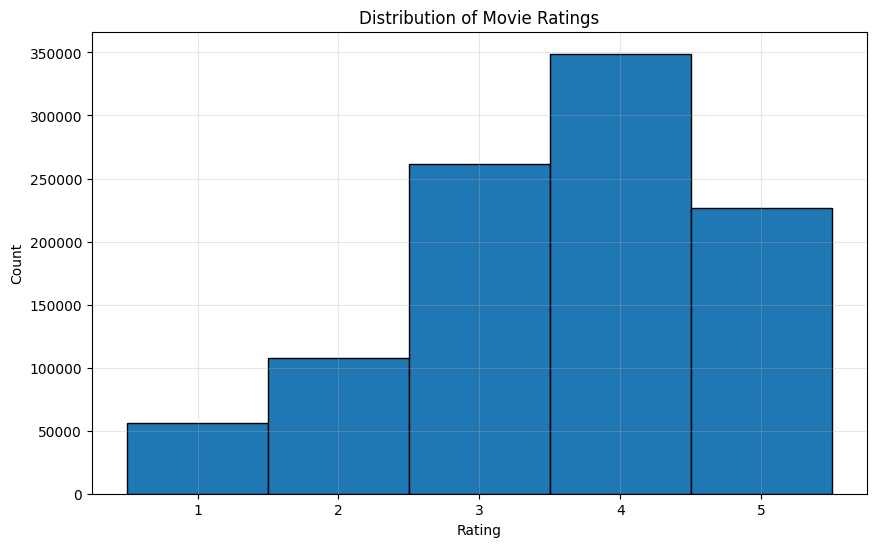

In [4]:
plt.figure(figsize=(10, 6))
ml_df["rating"].hist(bins=5, range=(0.5, 5.5), edgecolor="black")
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.xticks([1, 2, 3, 4, 5])
plt.show()

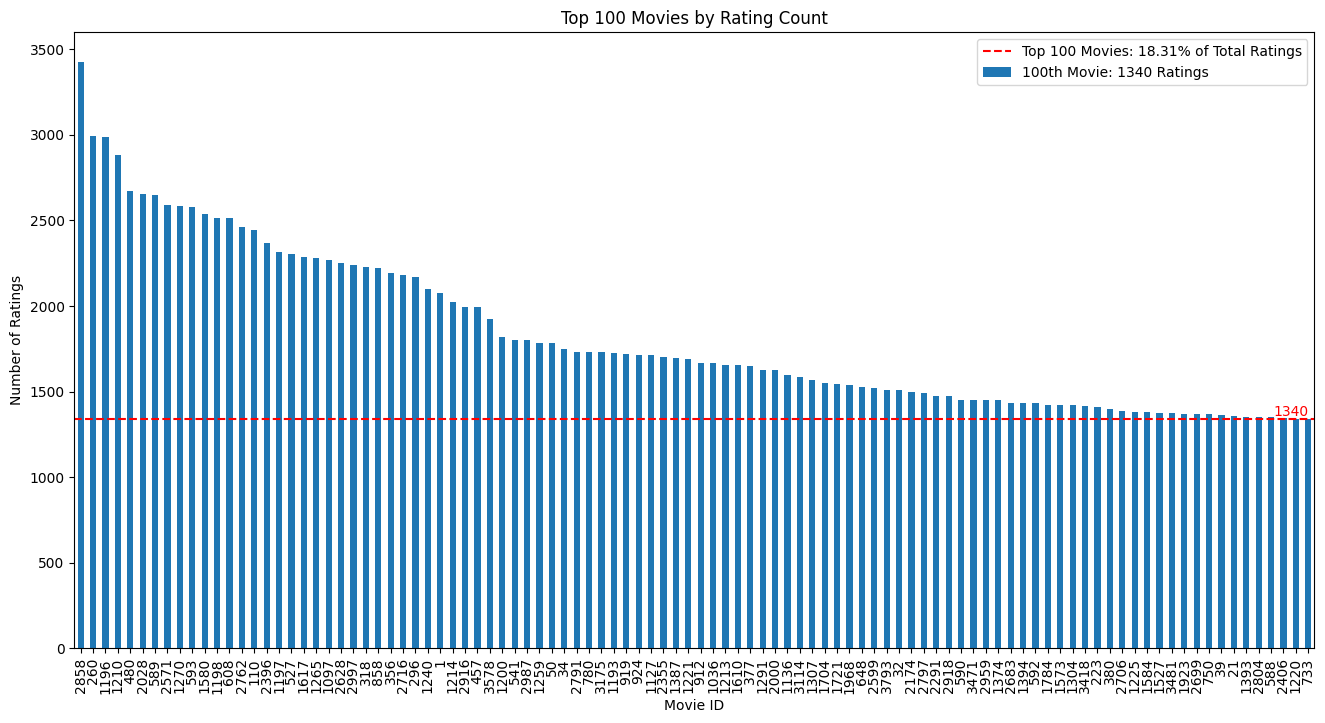

In [5]:
movie_counts = ml_df["item_id"].value_counts()
top_100_movies = movie_counts.head(100)
total_counts = movie_counts.sum()
top_100_percentage = (top_100_movies.sum() / total_counts) * 100

ratings_100th_movie = top_100_movies.iloc[-1]

plt.figure(figsize=(16, 8))
top_100_movies.plot(kind="bar")
plt.axhline(
    y=ratings_100th_movie,
    color="r",
    linestyle="--",
    label=f"100th Movie: {ratings_100th_movie} Ratings",
)

plt.text(
    x=len(top_100_movies) - 1,
    y=ratings_100th_movie,
    s=f"{ratings_100th_movie}",
    color="r",
    ha="right",
    va="bottom",
)

plt.title("Top 100 Movies by Rating Count")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.legend(
    [
        f"Top 100 Movies: {top_100_percentage:.2f}% of Total Ratings",
        f"100th Movie: {ratings_100th_movie} Ratings",
    ]
)

plt.show()

In [6]:
# 100 movies represent the following percentage of the total number of items
round((100 / ml_df.item_id.nunique()) * 100, 2)

2.7

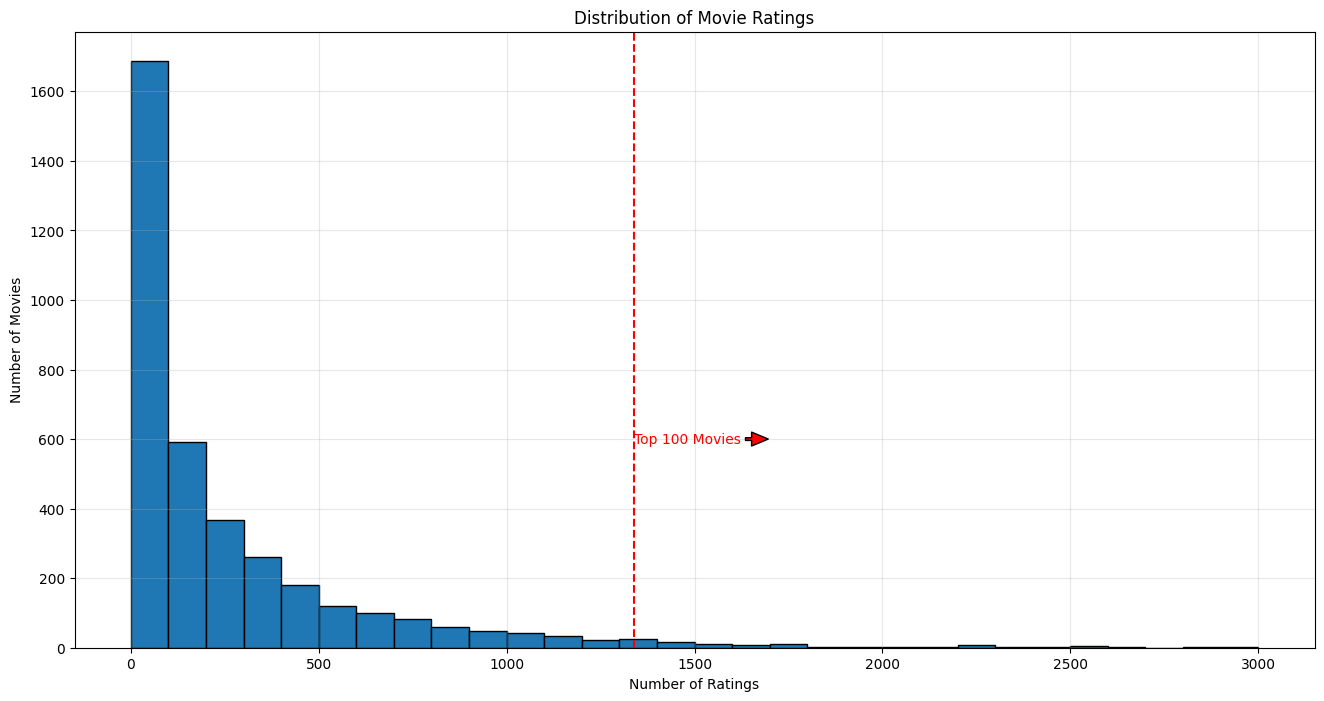

In [7]:
plt.figure(figsize=(16, 8))
movie_counts.hist(bins=range(0, 3100, 100), edgecolor="black")

plt.axvline(
    x=1340,
    color="r",
    linestyle="--",
    label="100 Ratings",
)

plt.annotate(
    "Top 100 Movies",
    xy=(1700, 600),  # Swapped with xytext
    xytext=(1340, 600),  # Swapped with xy
    arrowprops=dict(facecolor="red", shrink=0.05, headwidth=10, width=2),
    color="r",
    ha="left",
    va="center",
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.grid(True, alpha=0.3)
plt.show()

Number of movies needed for 90% of ratings: 1680
Total number of movies: 3706
Percentage of movies needed: 45.33%


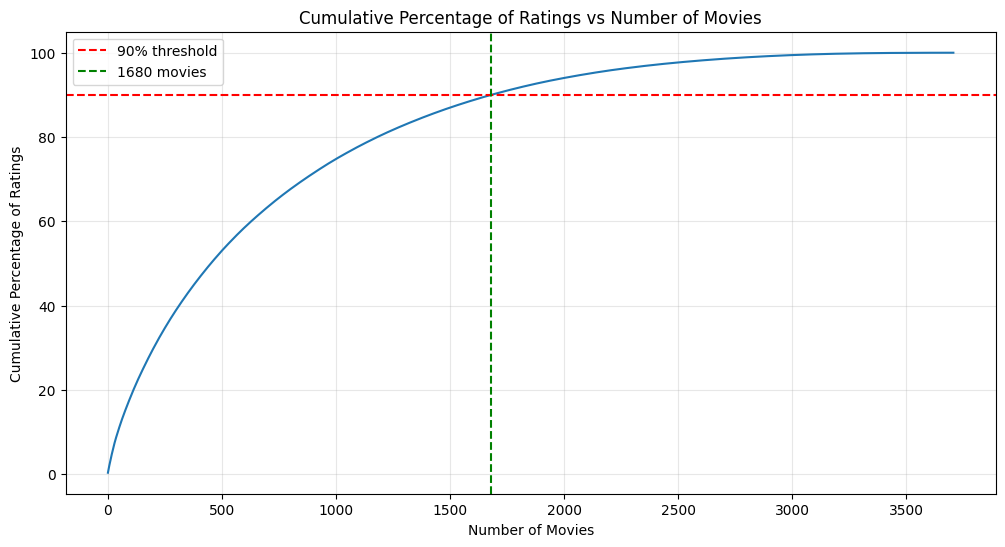

In [8]:
# so 2.7% percent of the movies account for 18.3% of the taotal number of views.
# Let's find out how many movies are required to account for 90% of the total number of views.

movie_counts = ml_df["item_id"].value_counts()
total_ratings = movie_counts.sum()

cumulative_sum = movie_counts.cumsum()
cumulative_percentage = (cumulative_sum / total_ratings) * 100

movies_for_90_percent = len(cumulative_percentage[cumulative_percentage <= 90])

print(f"Number of movies needed for 90% of ratings: {movies_for_90_percent}")
print(f"Total number of movies: {len(movie_counts)}")
print(
    f"Percentage of movies needed: {(movies_for_90_percent / len(movie_counts) * 100):.2f}%"
)

# Plot cumulative percentage
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_percentage) + 1), cumulative_percentage)
plt.axhline(y=90, color="r", linestyle="--", label="90% threshold")
plt.axvline(
    x=movies_for_90_percent,
    color="g",
    linestyle="--",
    label=f"{movies_for_90_percent} movies",
)
plt.title("Cumulative Percentage of Ratings vs Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Cumulative Percentage of Ratings")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [9]:
train_val_test_splits = Path("../data") / "train_val_test_splits" / "movielens_splits"

train_df = pd.read_csv(train_val_test_splits / "full_train.csv")
test_df = pd.read_csv(train_val_test_splits / "test.csv")

In [10]:
# Let's select the positive interactions and see where they are placed in terms
# of popularity/counts. For example, a movie id 1234 woud be place the 10th if
# is the 10th most popular movie in the train_df, where popularity is defined as
# the number of ratings.

positive_test_items = test_df[test_df["rating"] == 5].item_id.unique()

In [11]:
print(f"Number of unique positive test items: {len(positive_test_items)}")

Number of unique positive test items: 1588


In [12]:
# we have the movie_counts df that loos like this:
# item_id
# 2858    3428
# 260     2991
# 1196    2990
# 1210    2883
# ....

# and I want to find out the location of the positive items in the test set. For
# example, if the item_id 2858 is present in the positive_test_items, would be
# its popularity would be 1, if 260 is present, its popularity would be 2, and so on.
# I want a df with the item_id and its popularity (or location) in the movie_counts df.

positive_test_items_df = pd.DataFrame(positive_test_items, columns=["item_id"])

positive_test_items_df["popularity_rank"] = positive_test_items_df["item_id"].map(
    movie_counts.reset_index().reset_index().set_index("item_id")["index"]
)
positive_test_items_df["popularity_rank"] = (
    positive_test_items_df["popularity_rank"] + 1
)

In [13]:
positive_test_items_df

,item_id,popularity_rank
0,48,837
1,2002,314
2,3552,225
3,1954,150
4,2427,312
...,...,...
1583,3245,3382
1584,3269,652
1585,1598,1933
1586,3489,377


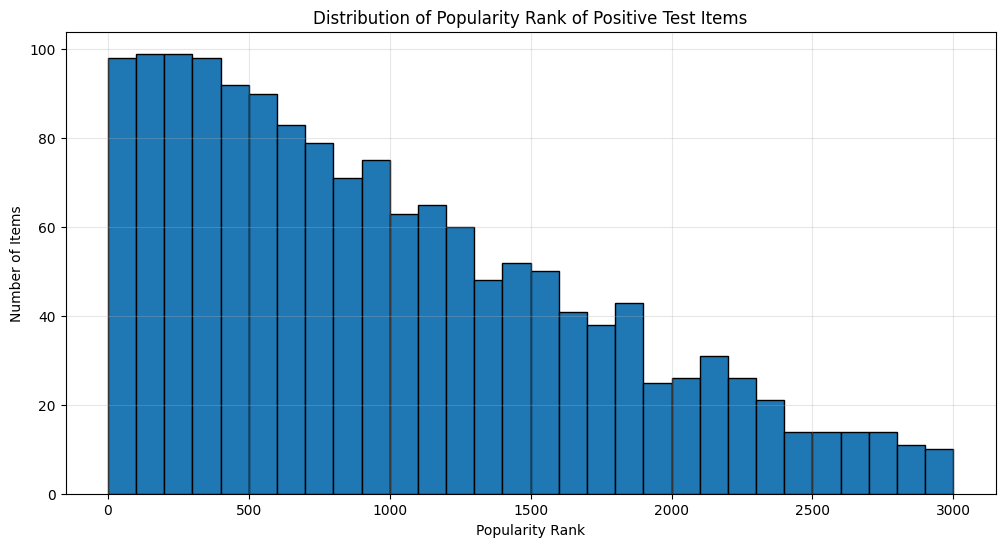

In [14]:
# Let's plot a histogram of bins of popularity_rank width of 10

plt.figure(figsize=(12, 6))
positive_test_items_df["popularity_rank"].hist(
    bins=range(0, 3100, 100), edgecolor="black"
)
plt.title("Distribution of Popularity Rank of Positive Test Items")
plt.xlabel("Popularity Rank")
plt.ylabel("Number of Items")
plt.grid(True, alpha=0.3)
plt.show()